In [1]:
# Cell 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# Cell 2: Clone GitHub Repository

!git clone https://github.com/sunairakhan/KMeans-Customer-Segmentation.git

Cloning into 'KMeans-Customer-Segmentation'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 16 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 5.27 KiB | 5.27 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [3]:
# Cell 3: Set Project Path

project_path = "/content/KMeans-Customer-Segmentation"
dataset_path = os.path.join(project_path, "dataset")
model_path = os.path.join(project_path, "model")

print("Project Path:", project_path)
print("Dataset Path:", dataset_path)
print("Model Path:", model_path)

Project Path: /content/KMeans-Customer-Segmentation
Dataset Path: /content/KMeans-Customer-Segmentation/dataset
Model Path: /content/KMeans-Customer-Segmentation/model


In [4]:
# Cell 4: Load Standard Dataset

standard_data = pd.read_csv(os.path.join(dataset_path, "Mall_Customers.csv"))

standard_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
# Cell 5: Check Dataset Information

print("Dataset Shape:", standard_data.shape)

print("\nColumn Names:")
print(standard_data.columns)

print("\nMissing Values:")
print(standard_data.isnull().sum())

standard_data.head()

Dataset Shape: (200, 5)

Column Names:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
# Cell 6: Select Features for K-Means Clustering

X = standard_data[["Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [7]:
# Cell 7: Data Preprocessing Using StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Data:")
print(X_scaled[:5])

Scaled Data:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


In [8]:
# Cell 3: Set Project Path

import os

project_path = "/content/KMeans-Customer-Segmentation"
dataset_path = os.path.join(project_path, "dataset")
model_path = os.path.join(project_path, "model")

print("Project Path:", project_path)
print("Dataset Path:", dataset_path)
print("Model Path:", model_path)

Project Path: /content/KMeans-Customer-Segmentation
Dataset Path: /content/KMeans-Customer-Segmentation/dataset
Model Path: /content/KMeans-Customer-Segmentation/model


In [9]:
# Cell 4: Load Standard Dataset

standard_data = pd.read_csv(os.path.join(dataset_path, "Mall_Customers.csv"))

standard_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [10]:
# Cell 5: Check Dataset Information

print("Dataset Shape:", standard_data.shape)

print("\nColumn Names:")
print(standard_data.columns)

print("\nMissing Values:")
print(standard_data.isnull().sum())

standard_data.head()

Dataset Shape: (200, 5)

Column Names:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [11]:
# Cell 6: Select Features for K-Means Clustering

X = standard_data[["Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [12]:
# Cell 7: Data Preprocessing Using StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Data:")
print(X_scaled[:5])

Scaled Data:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


In [13]:
# Cell 8: Elbow Method to Find Optimal K

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

print("WCSS values:")
print(wcss)

WCSS values:
[399.99999999999994, 269.69101219276405, 157.70400815035939, 108.92131661364358, 65.56840815571681, 55.057348270385965, 44.86475569922555, 37.22818767758587, 32.39226763033118, 29.981897788243703]


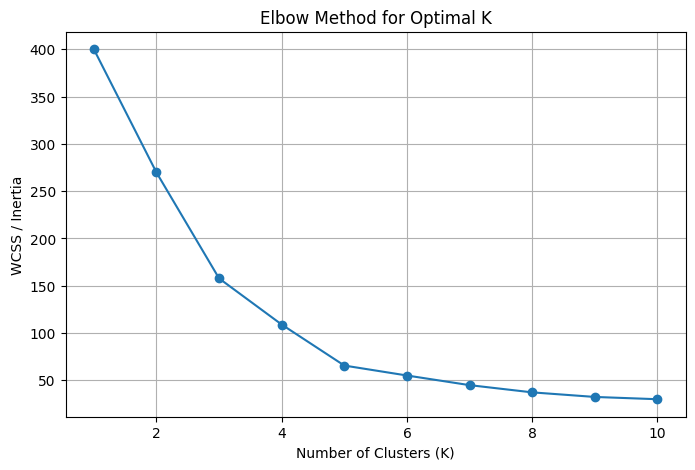

In [14]:
# Cell 9: Plot Elbow Curve

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.grid(True)
plt.show()

In [15]:
# Cell 10: Train Final K-Means Model

optimal_k = 5

kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
standard_data["Cluster"] = kmeans_model.fit_predict(X_scaled)

standard_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [16]:
# Cell 11: Check Number of Customers in Each Cluster

print("Number of customers in each cluster:")
print(standard_data["Cluster"].value_counts().sort_index())

Number of customers in each cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [17]:
# Cell 12: Save the Trained Model and Scaler

joblib.dump(kmeans_model, os.path.join(model_path, "210117_kmeans_model.pkl"))
joblib.dump(scaler, os.path.join(model_path, "210117_scaler.pkl"))

print("Model saved as: 210117_kmeans_model.pkl")
print("Scaler saved as: 210117_scaler.pkl")

Model saved as: 210117_kmeans_model.pkl
Scaler saved as: 210117_scaler.pkl


In [20]:
# Cell 13: Load Custom Dataset

custom_data = pd.read_csv(os.path.join(dataset_path, "custom_customers.csv"))

custom_data.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,21,18,72
1,24,22,80
2,30,35,55
3,35,45,40
4,42,60,35


In [19]:
# Cell 14: Check Custom Dataset Information

print("Custom Dataset Shape:", custom_data.shape)

print("\nColumn Names:")
print(custom_data.columns)

print("\nMissing Values:")
print(custom_data.isnull().sum())

custom_data

Custom Dataset Shape: (10, 3)

Column Names:
Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

Missing Values:
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,Age,Annual Income (k$),Spending Score (1-100)
0,21,18,72
1,24,22,80
2,30,35,55
3,35,45,40
4,42,60,35
5,50,70,30
6,23,20,88
7,29,38,65
8,47,75,25
9,33,50,50


In [21]:
# Cell 15: Scale Custom Data Using Same Scaler

custom_X = custom_data[["Annual Income (k$)", "Spending Score (1-100)"]]

custom_X_scaled = scaler.transform(custom_X)

print("Scaled Custom Data:")
print(custom_X_scaled)

Scaled Custom Data:
[[-1.62449091  0.84631002]
 [-1.47181319  1.15688251]
 [-0.97561061  0.18634349]
 [-0.59391632 -0.39597992]
 [-0.02137488 -0.59008772]
 [ 0.36031941 -0.78419553]
 [-1.54815205  1.46745499]
 [-0.86110232  0.5745591 ]
 [ 0.55116656 -0.97830333]
 [-0.40306917 -0.00776431]]


In [22]:
# Cell 16: Predict Clusters for Custom Data

custom_data["Assigned Cluster"] = kmeans_model.predict(custom_X_scaled)

custom_data

,Age,Annual Income (k$),Spending Score (1-100),Assigned Cluster
0,21,18,72,2
1,24,22,80,2
2,30,35,55,0
3,35,45,40,0
4,42,60,35,0
5,50,70,30,3
6,23,20,88,2
7,29,38,65,2
8,47,75,25,3
9,33,50,50,0


In [23]:
# Cell 17: Show Final Custom Prediction Table

print("Custom Customer Cluster Assignment:")

custom_data

Custom Customer Cluster Assignment:


,Age,Annual Income (k$),Spending Score (1-100),Assigned Cluster
0,21,18,72,2
1,24,22,80,2
2,30,35,55,0
3,35,45,40,0
4,42,60,35,0
5,50,70,30,3
6,23,20,88,2
7,29,38,65,2
8,47,75,25,3
9,33,50,50,0


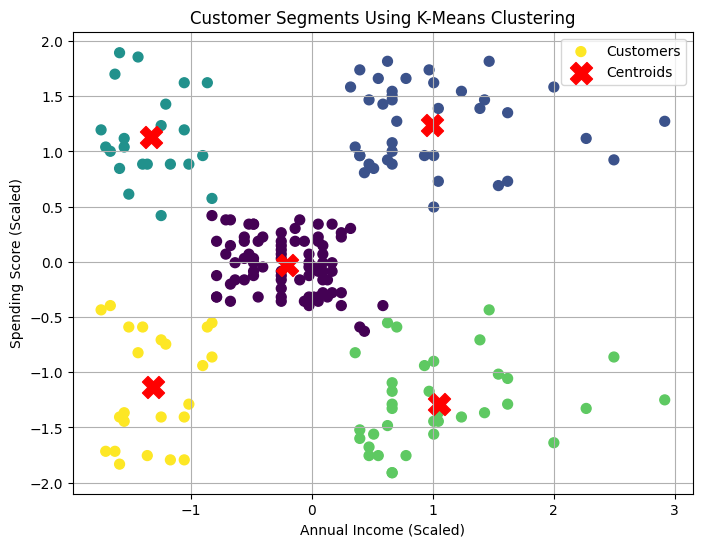

In [24]:
# Cell 18: Cluster Scatter Plot with Centroids

plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=standard_data["Cluster"],
    cmap="viridis",
    s=50,
    label="Customers"
)

plt.scatter(
    kmeans_model.cluster_centers_[:, 0],
    kmeans_model.cluster_centers_[:, 1],
    s=250,
    marker="X",
    c="red",
    label="Centroids"
)

plt.title("Customer Segments Using K-Means Clustering")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# Cell 19: Cluster Centers Table

centers_original = scaler.inverse_transform(kmeans_model.cluster_centers_)

cluster_centers = pd.DataFrame(
    centers_original,
    columns=["Annual Income (k$)", "Spending Score (1-100)"]
)

cluster_centers["Cluster"] = cluster_centers.index

cluster_centers = cluster_centers[["Cluster", "Annual Income (k$)", "Spending Score (1-100)"]]

cluster_centers

,Cluster,Annual Income (k$),Spending Score (1-100)
0,0,55.296296,49.518519
1,1,86.538462,82.128205
2,2,25.727273,79.363636
3,3,88.200000,17.114286
4,4,26.304348,20.913043


# Cell 20: Cluster Interpretation

The K-Means model divided the customers into 5 different groups based on Annual Income and Spending Score. Customers in one cluster may have low income but high spending, while another cluster may have high income but low spending. This clustering result can help a business understand customer behavior and make better marketing decisions.

In [26]:
# Cell 21: Final Confirmation

print("K-Means Clustering Assignment Completed Successfully.")
print("Outputs included:")
print("1. Elbow Curve Plot")
print("2. Cluster Scatter Plot with Centroids")
print("3. Custom Prediction Table")
print("4. Cluster Interpretation")
print("5. Saved K-Means Model and Scaler")

K-Means Clustering Assignment Completed Successfully.
Outputs included:
1. Elbow Curve Plot
2. Cluster Scatter Plot with Centroids
3. Custom Prediction Table
4. Cluster Interpretation
5. Saved K-Means Model and Scaler
